In [ ]:
# DECISION TREE:

In [ ]:
# Objective:
# The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse 
# the performance of the model, and interpret the results.

In [ ]:
# Tasks:

In [ ]:
# 1. Data Preparation:
# Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [2]:
# Load the Dataset :
import pandas as pd 
df = pd.read_excel("heart_disease.xlsx", sheet_name= "Heart_disease")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [3]:
# 2. Exploratory Data Analysis (EDA):
# A. Perform exploratory data analysis to understand the structure of the dataset.

In [4]:
# Head of the Dataset 
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [5]:
# Head of the Dataset 
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [6]:
# Shape of the Dataset 
df.shape

(908, 13)

In [7]:
# Columns of Dataset 
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [8]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [9]:
# Statistical summary 
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [10]:
# B.Check for missing values, outliers, and inconsistencies in the data.

In [11]:
# Check the Missing Values 
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [12]:
# Check the Duplicates values 
df.duplicated().sum()

np.int64(1)

In [13]:
# Drop the Duplicated 
df.drop_duplicates(inplace  = True)

In [14]:
# Verify 
df.duplicated().sum()

np.int64(0)

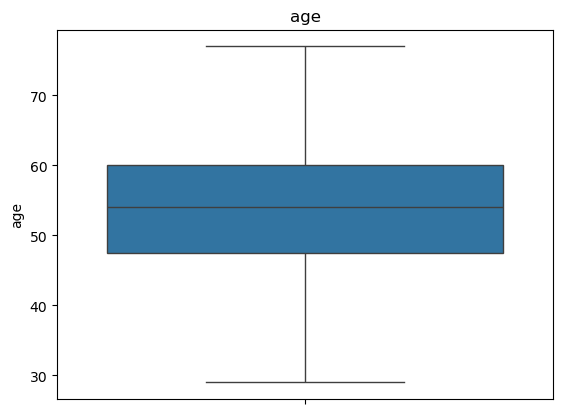

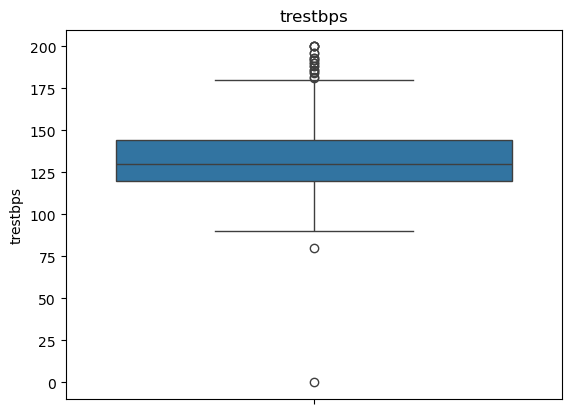

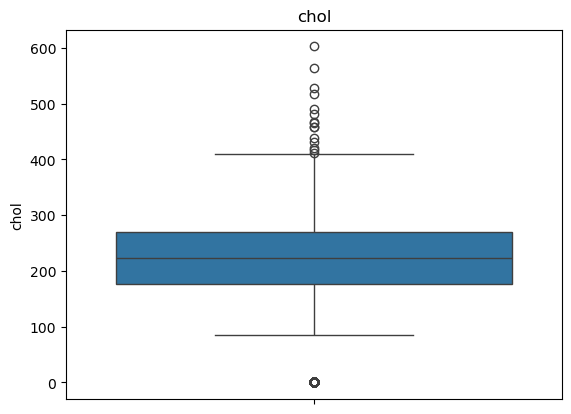

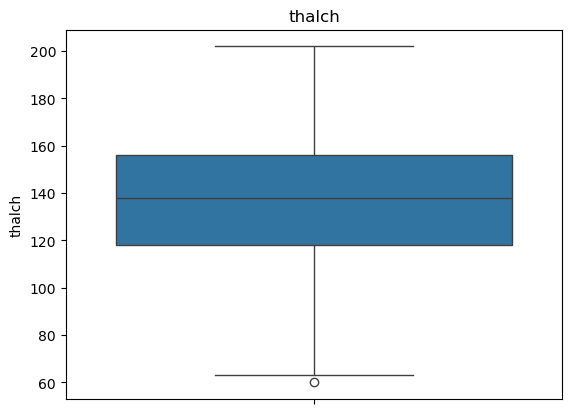

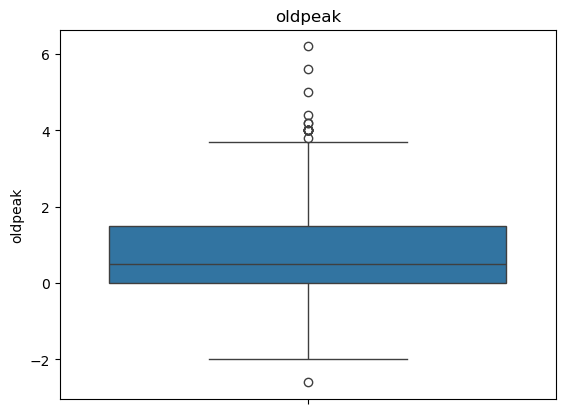

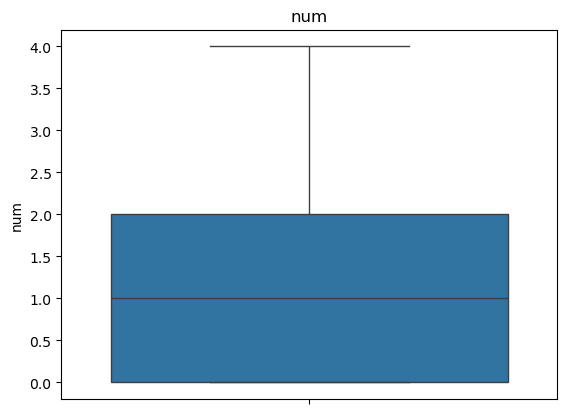

In [15]:
# Check Ouitlier 
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot (df[col])
    plt.title(col)
    plt.show()

In [16]:
# Ouitlier Capping 
for i in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    IQR = q1 - q3 
    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5*IQR

    df[i] = df[i].clip(lower_bound, upper_bound)

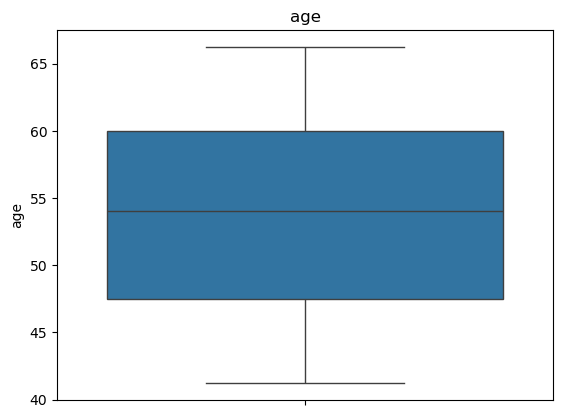

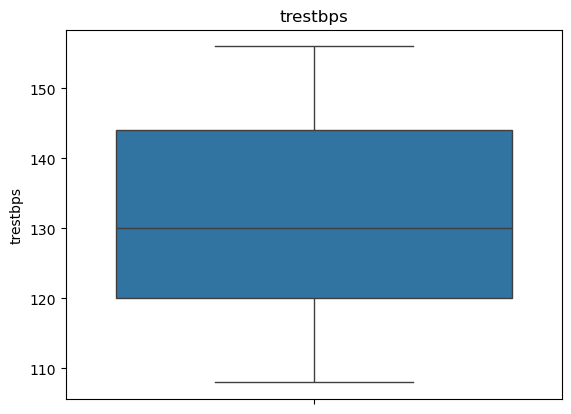

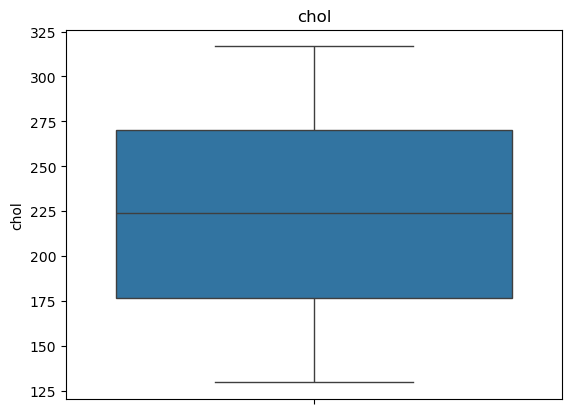

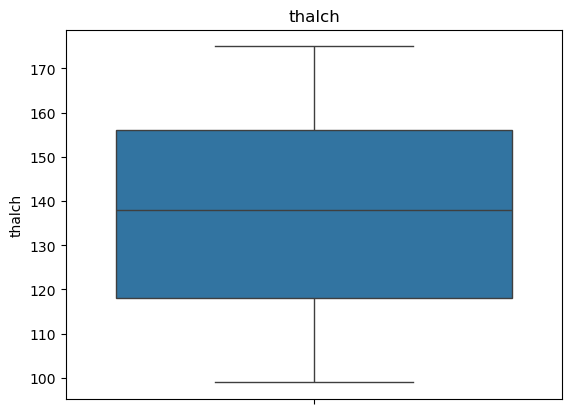

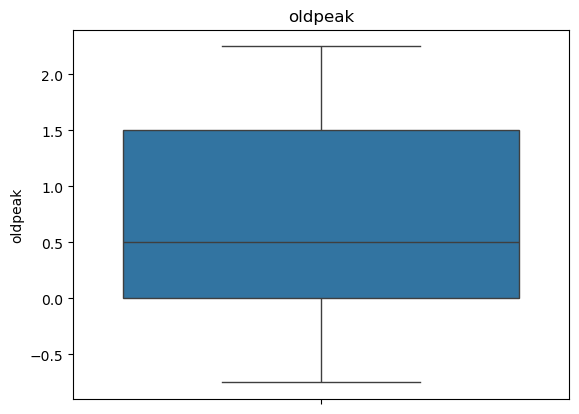

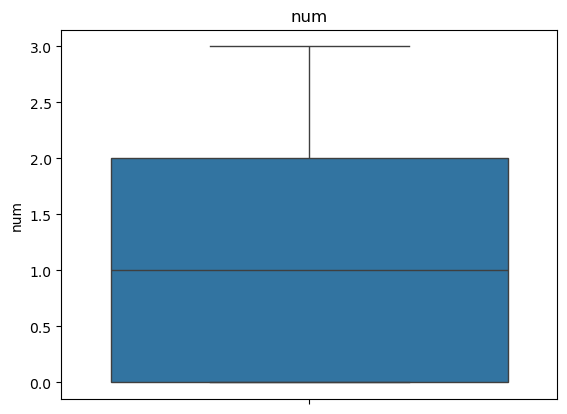

In [17]:
# Verify 
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [18]:
# C.Visualize the distribution of features, including histograms, box plots, and correlation matrices.

In [19]:
# Extract the Categorical columns and Numerical Columns 
cat_cols = df.select_dtypes(include = 'object').columns
num_cols = df.select_dtypes(include = ['int','float']).columns

print("Categorical Columns:\n", cat_cols)
print("Numerical Columns: \n", num_cols)

Categorical Columns:
 Index(['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], dtype='object')
Numerical Columns: 
 Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')


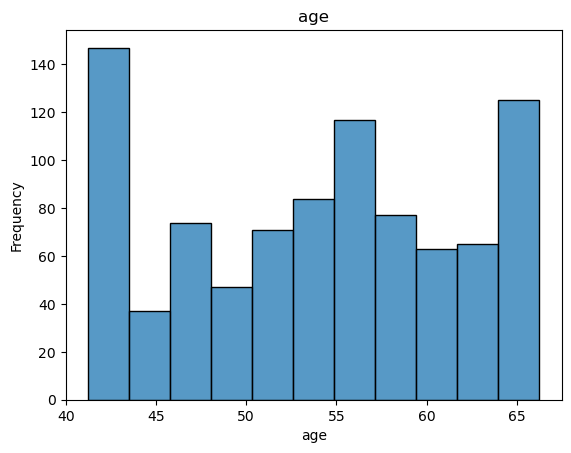

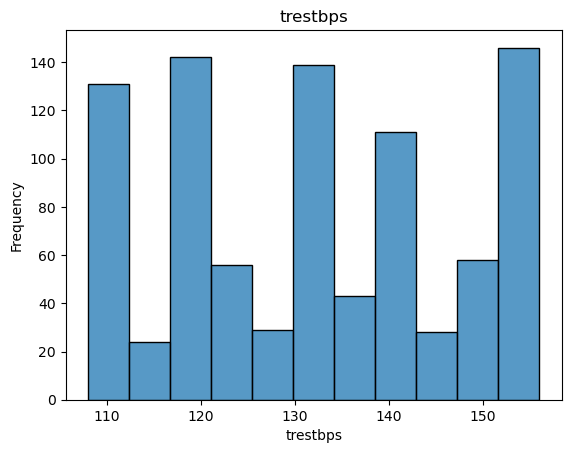

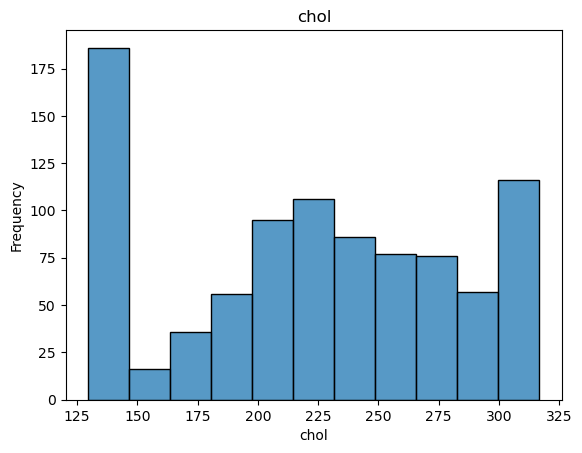

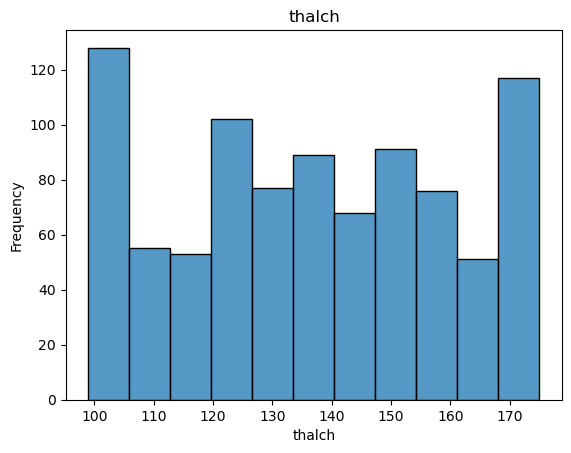

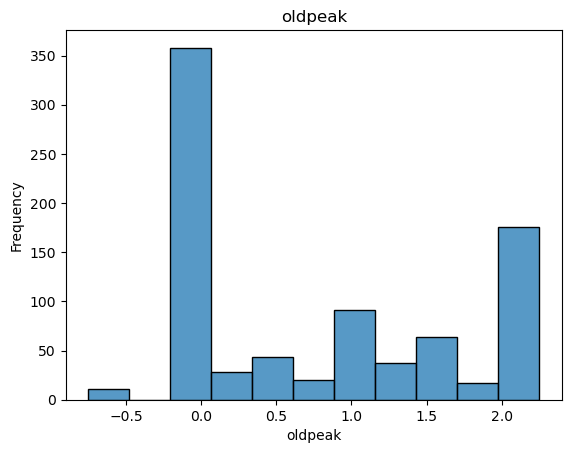

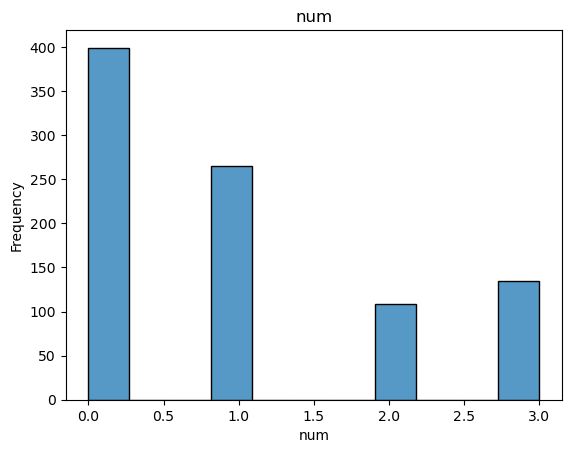

In [20]:
# HistPlot for Numerical columns 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in num_cols :
    sns.histplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

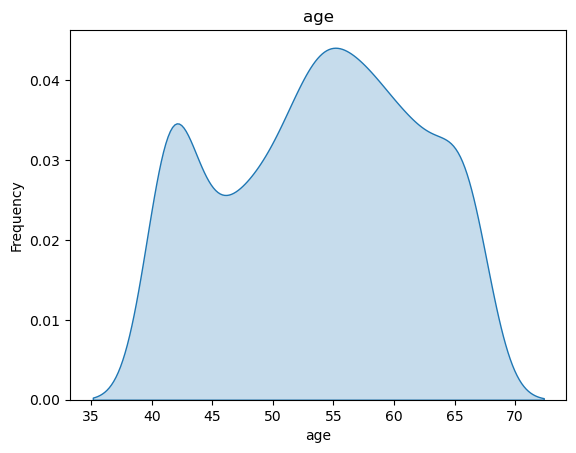

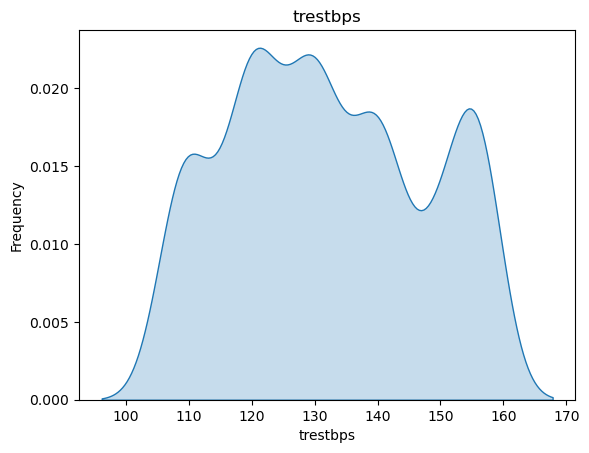

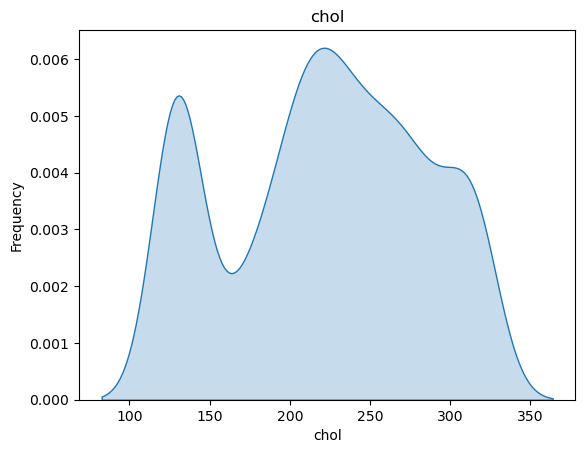

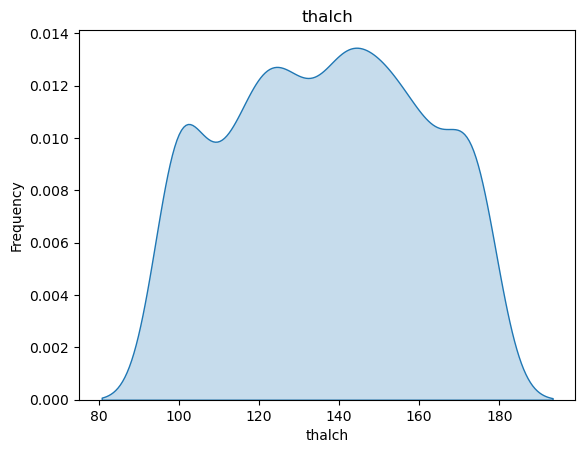

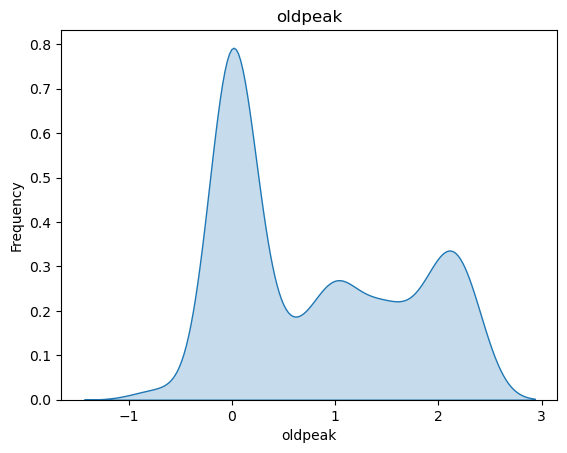

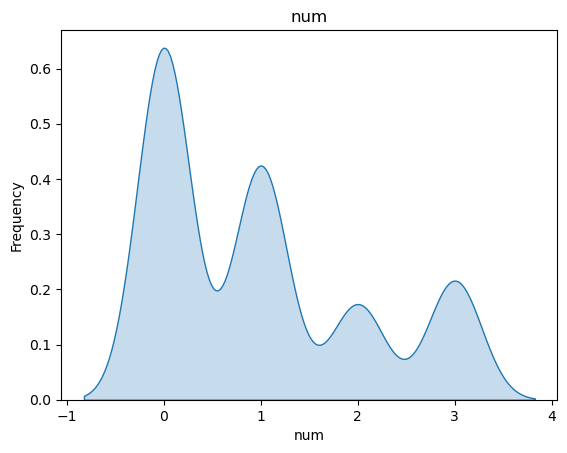

In [21]:
# KDE PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in num_cols:
    sns.kdeplot(df[col], fill = True)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

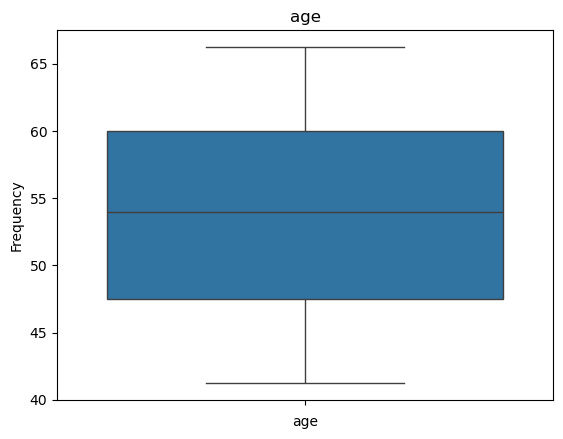

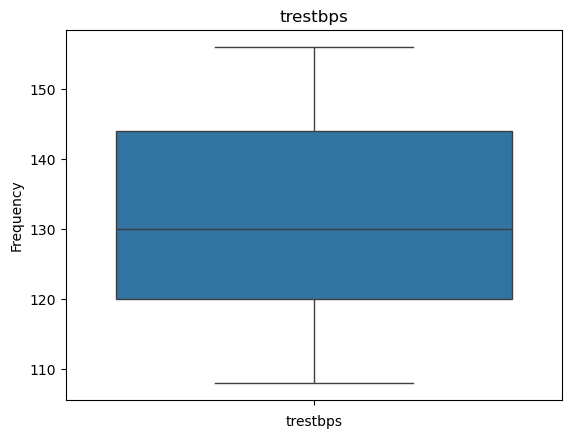

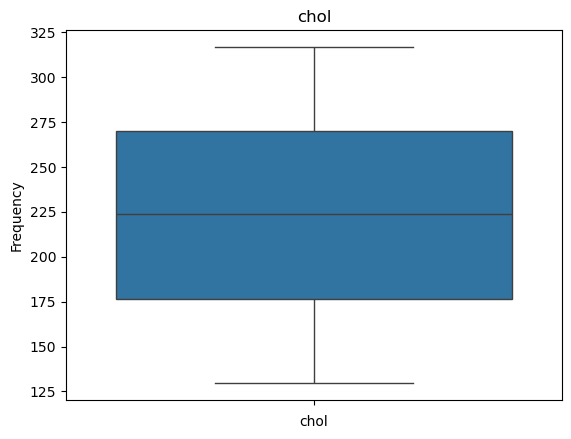

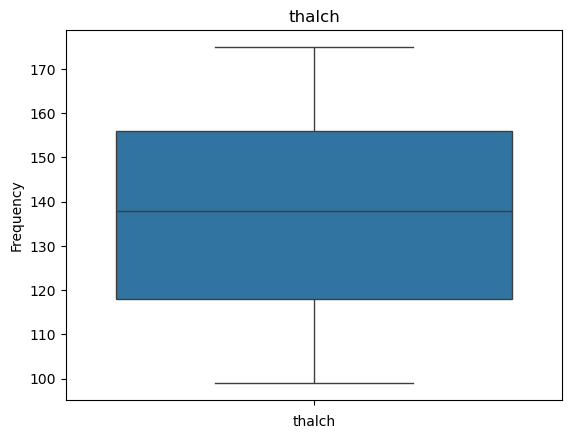

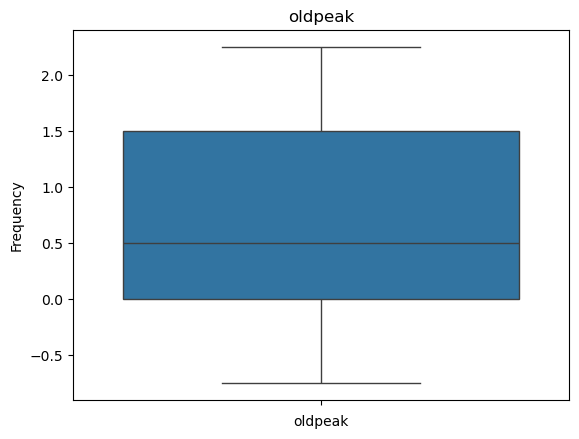

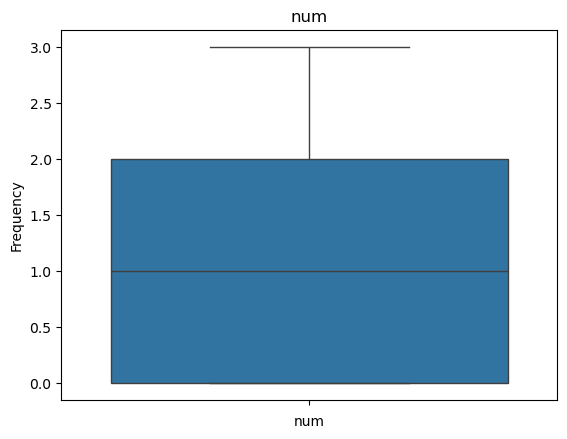

In [22]:
# BOX PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in num_cols :
    sns.boxplot (df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

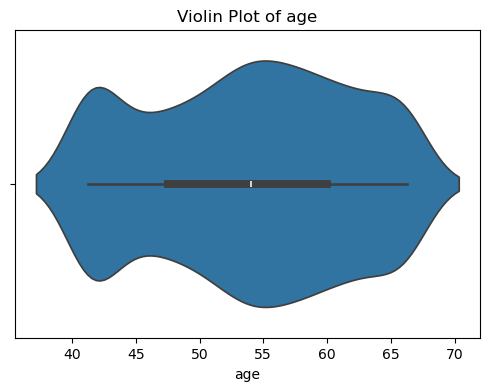

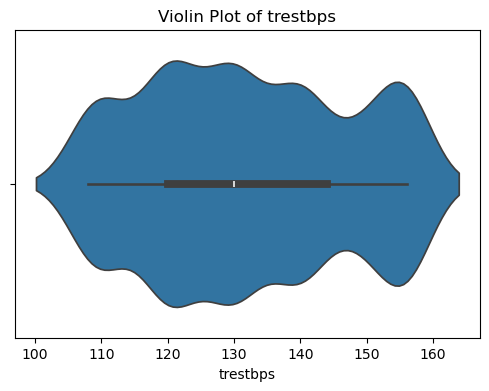

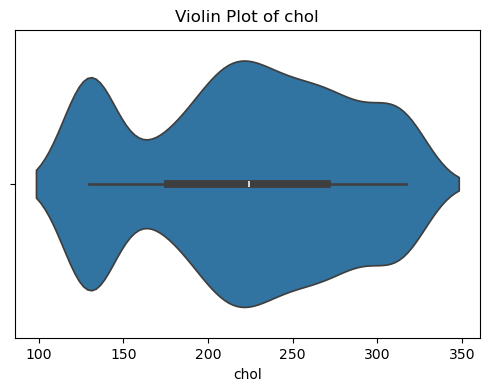

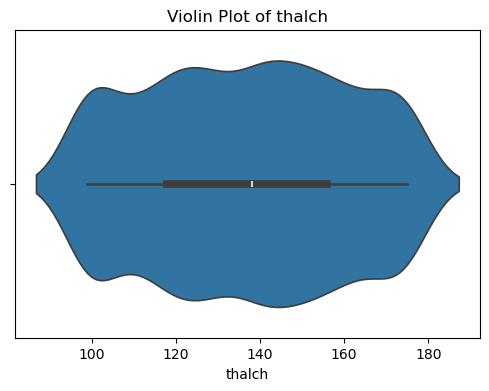

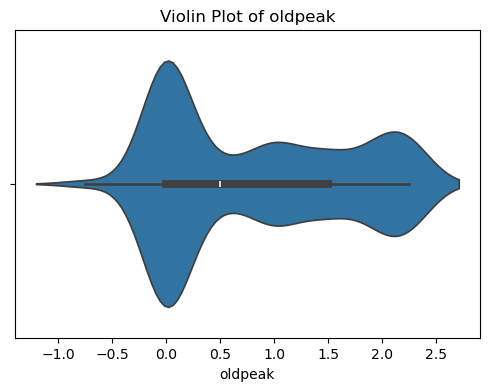

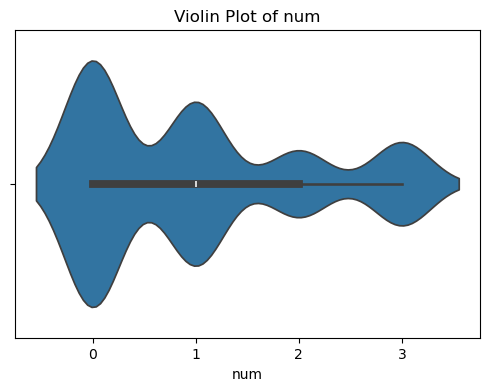

In [23]:
# Violin Plot
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.violinplot(x=df[col])
    plt.title(f"Violin Plot of {col}")
    plt.show()

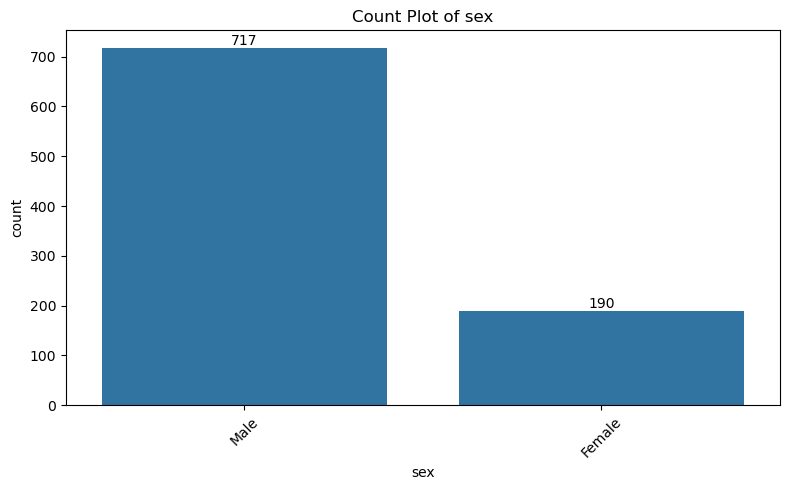

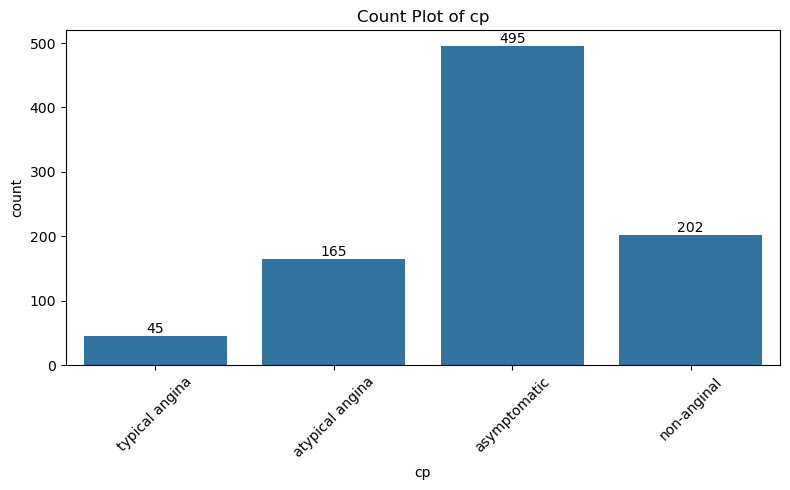

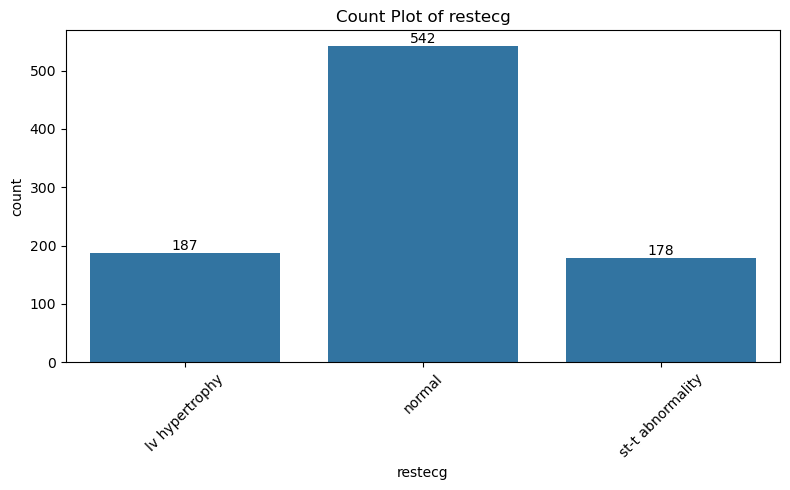

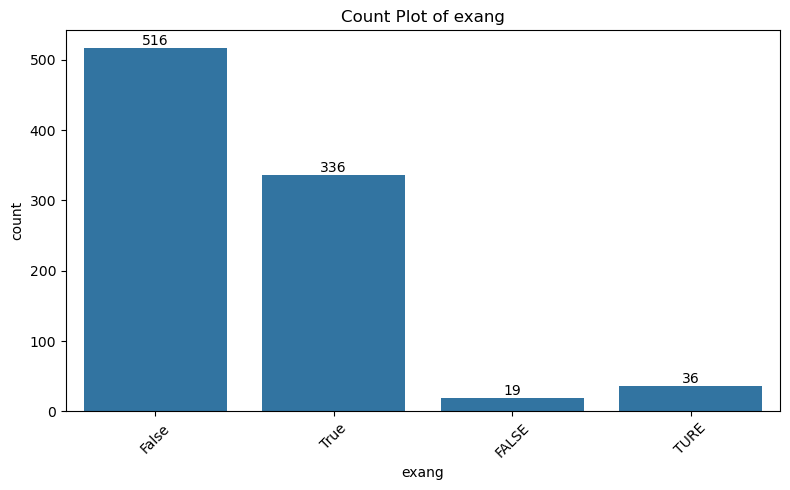

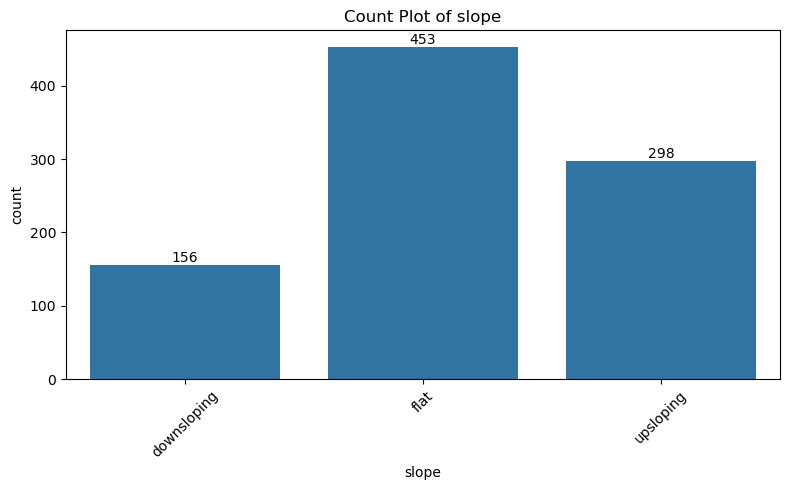

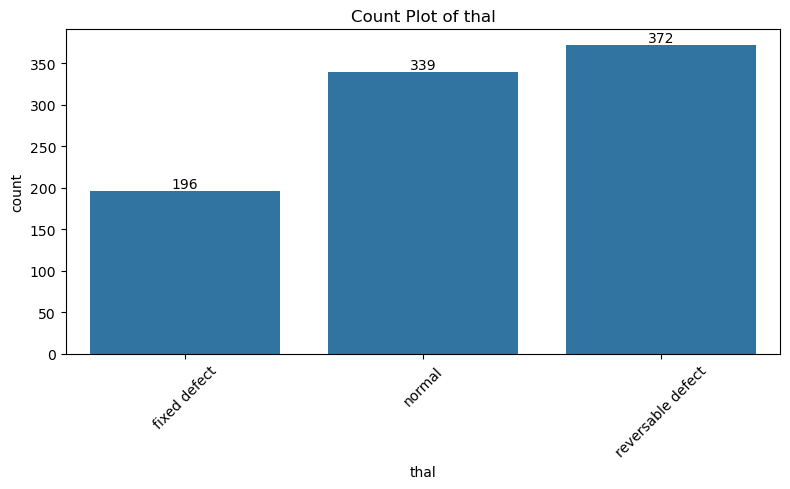

In [24]:
# COUNT PLOT FOR CATEGORICAL COLUMNS 

import seaborn as sns
import matplotlib.pyplot as plt

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:

    plt.figure(figsize=(8,5))

    ax = sns.countplot(data=df, x=col)

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

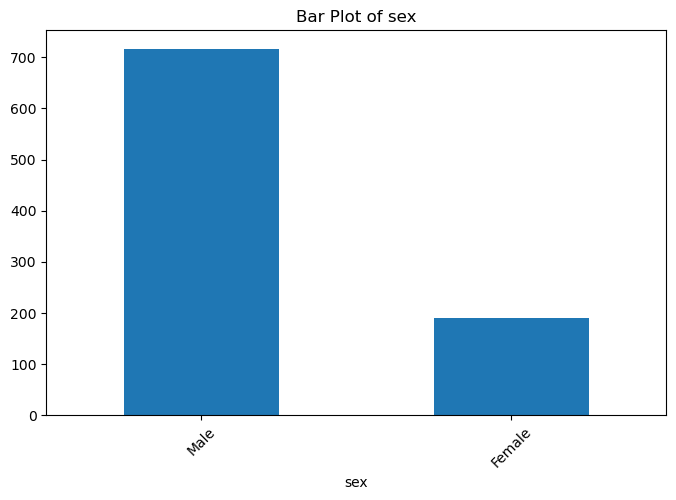

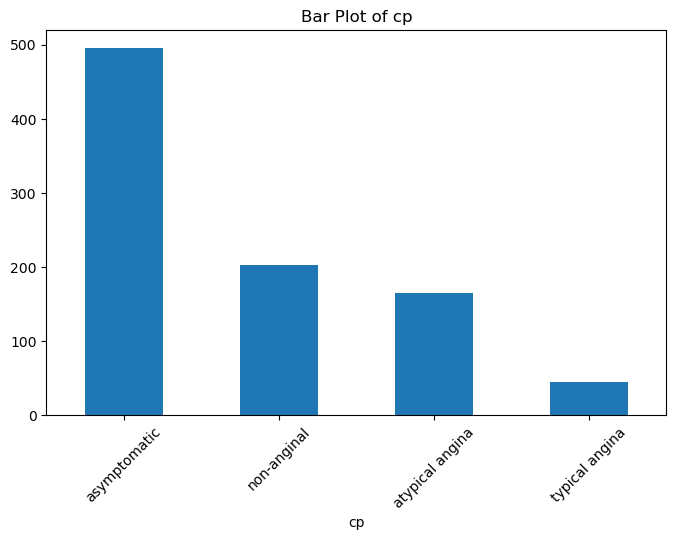

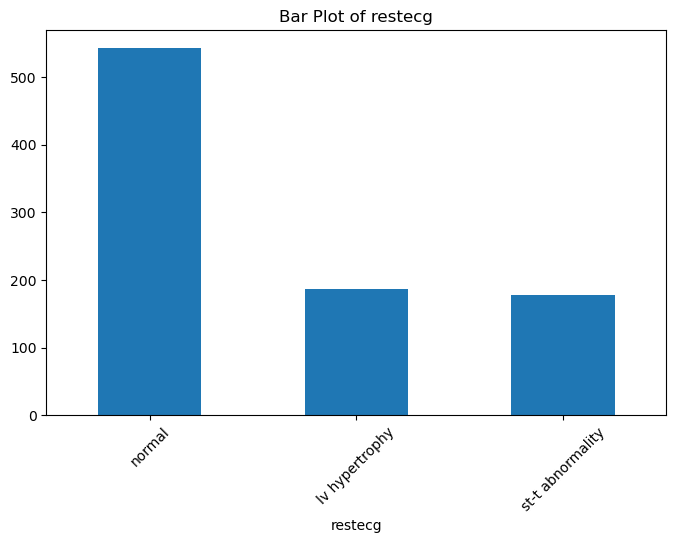

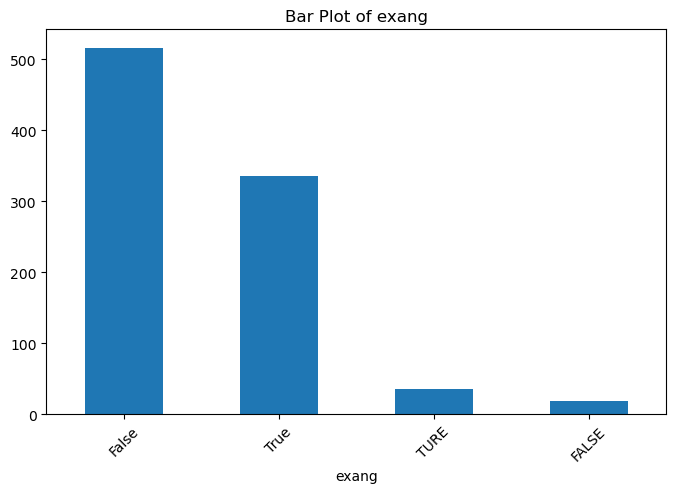

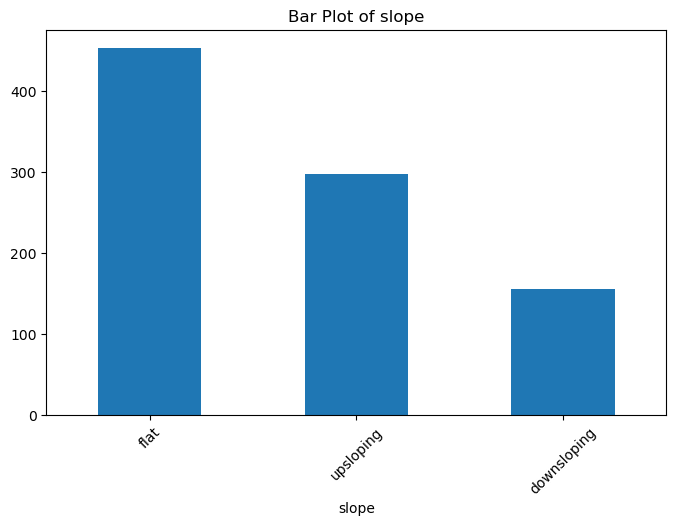

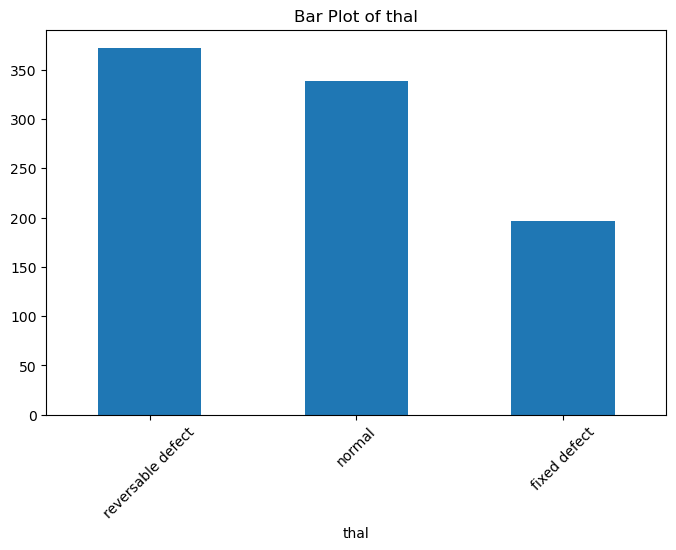

In [25]:
# BAR PLOT 
import matplotlib.pyplot as plt

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:

    plt.figure(figsize=(8,5))

    df[col].value_counts().plot(kind="bar")

    plt.title(f"Bar Plot of {col}")
    plt.xticks(rotation=45)

    plt.show()

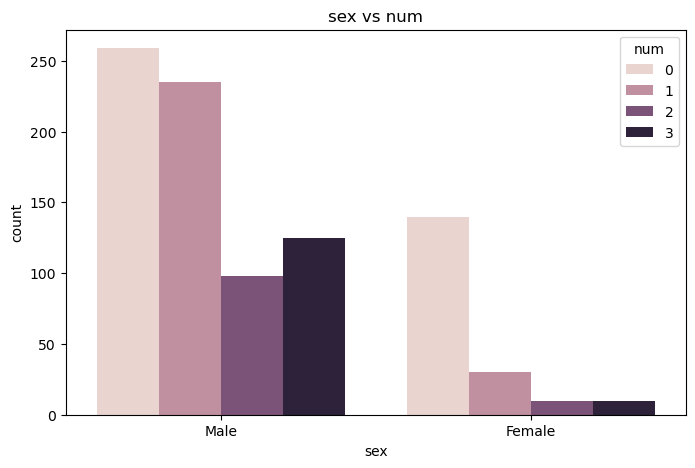

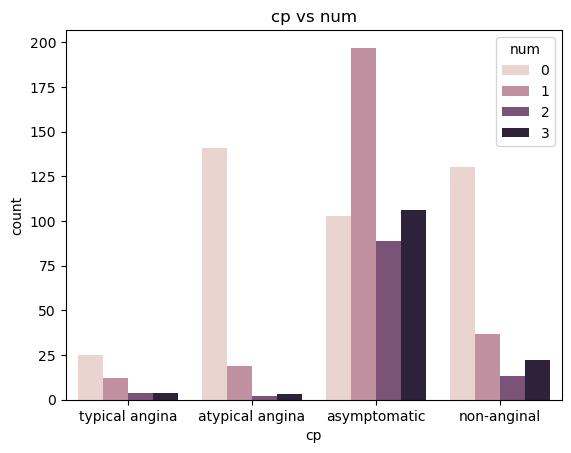

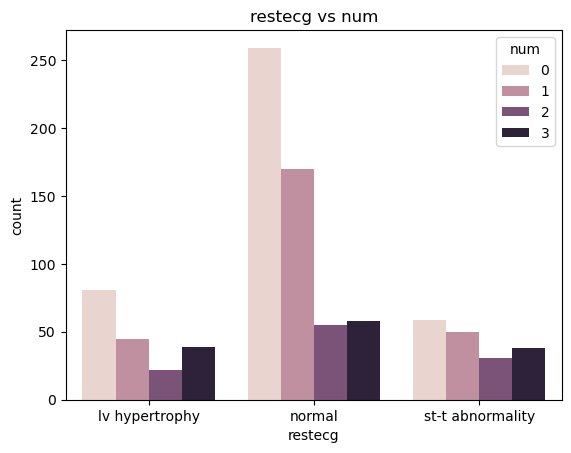

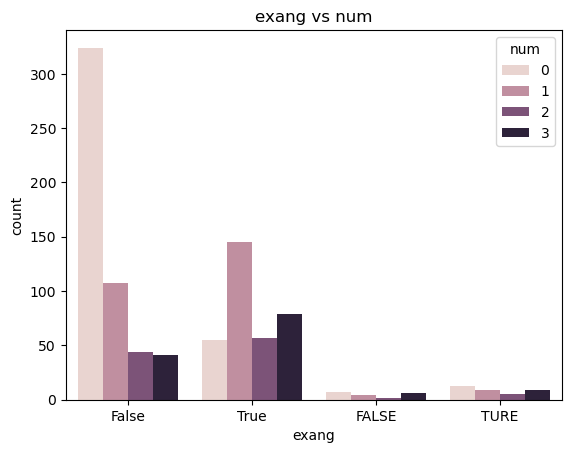

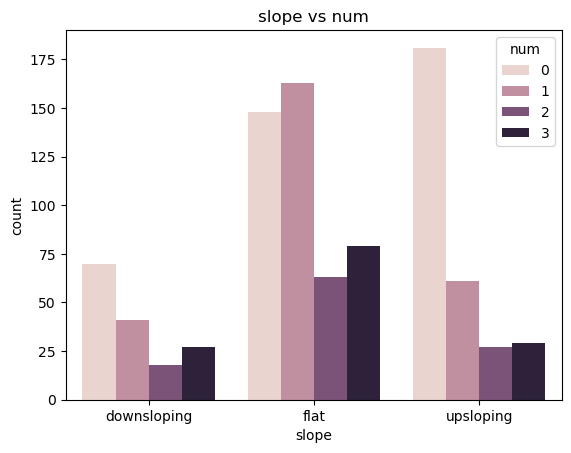

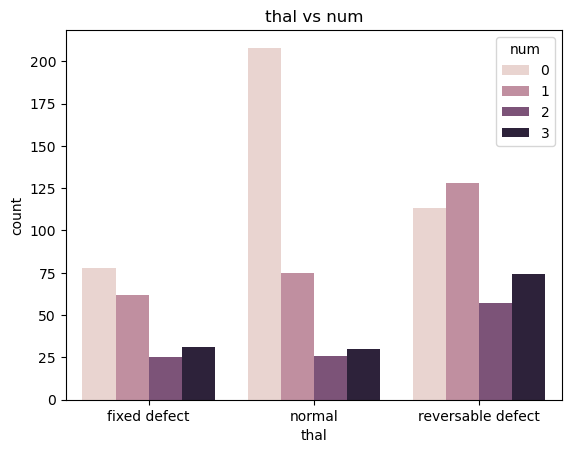

In [26]:
# Feature vs Target 
plt.figure(figsize=(8,5))
for col in cat_cols :
    sns.countplot(
        data = df,
        x = col,
        hue = "num"
    )
    plt.title(f"{col} vs num")
    plt.show()

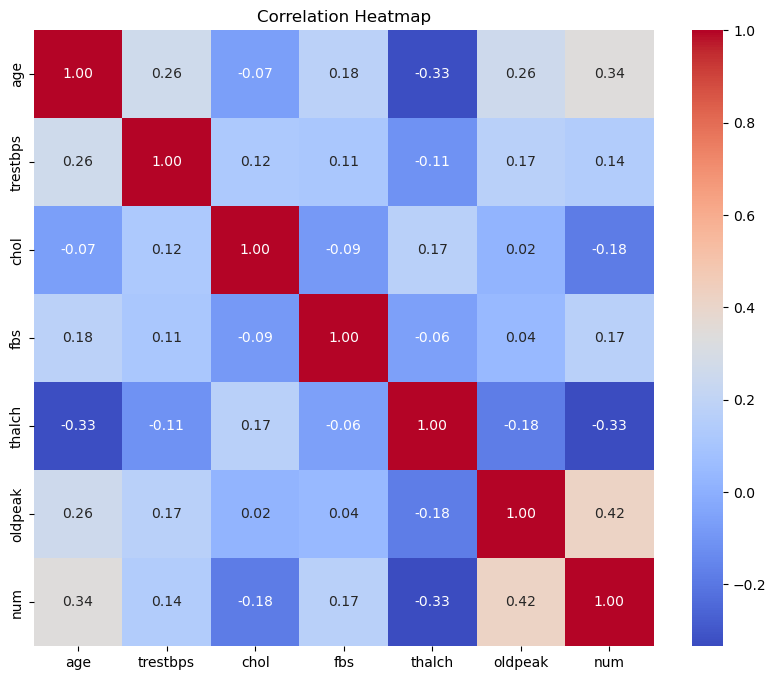

In [27]:
# CORRELATION METRICS
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# 3. Feature Engineering:
# If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [28]:
# Scaling
df['fbs'] = df['fbs'].astype('str')
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include = 'object').columns:
    df[col] = le.fit_transform(df[col].astype('str'))

In [29]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.00,1,3,145,233.0,1,0,150,1,2.25,0,0,0
1,41.25,1,1,135,203.0,0,1,132,1,0.00,1,0,0
2,57.00,1,0,140,192.0,0,1,148,1,0.40,1,0,0
3,52.00,1,3,118,186.0,0,0,175,1,0.00,1,0,0
4,57.00,1,0,110,201.0,0,1,126,3,1.50,1,0,0


In [30]:
# Check Missing Values 
missing = pd.DataFrame({
    "Missing" : df.isnull().sum(),
    "Percentage" : (df.isnull().sum() / len(df) ) * 100
})

missing.sort_values("Percentage", ascending = False)

,Missing,Percentage
oldpeak,62,6.835722
age,0,0.000000
sex,0,0.000000
cp,0,0.000000
trestbps,0,0.000000
chol,0,0.000000
fbs,0,0.000000
restecg,0,0.000000
thalch,0,0.000000
exang,0,0.000000


In [31]:
# Handle Missing Values 

df['oldpeak']  = df['oldpeak'].fillna(df['oldpeak'].mean())

In [32]:
# Verify 
missing = pd.DataFrame({
    "Missing" : df.isnull().sum(),
    "Percentage" : (df.isnull().sum() / len(df) ) * 100
})

missing.sort_values("Percentage", ascending = False)

,Missing,Percentage
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalch,0,0.0
exang,0,0.0
oldpeak,0,0.0


In [33]:
# 4. Decision Tree Classification:
# A.Split the dataset into training and testing sets (e.g., using an 80-20 split).

In [34]:
# Extract Features and Target 
x = df.drop(columns = 'num')
y = df['num']

In [35]:
# Split the Data 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [36]:
# Final Checks 
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:",y_test.shape)

Shape of x_train: (725, 12)
Shape of x_test: (182, 12)
Shape of y_train: (725,)
Shape of y_test: (182,)


In [37]:
# B. Implement a Decision Tree Classification model using a library like scikit-learn.

In [38]:
# Implementation of Decision Tree Classification 
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

In [ ]:
# C.Train the model on the training set and evaluate its performancC.Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).e on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [39]:
# Train the Model
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
# In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
# On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [41]:
# Prediction 
y_pred  = dt.predict(x_test)

In [42]:
# Evaluate the Performance 

from sklearn.metrics import (
            accuracy_score,
            precision_score,
            recall_score,
            f1_score,
            roc_auc_score
)

# Accuracy Score
accu_sco = accuracy_score (y_test, y_pred)
print("Accuracy Score:", accu_sco)

# Precision Score
pre_sco = precision_score(y_test, y_pred, average= "micro")
print("Precision Score:",pre_sco)

# Recall Score 
rec_sco = recall_score(y_test, y_pred, average = "micro")
print("Recall Score:", rec_sco)

# F1 Score
f1_sco = f1_score(y_test, y_pred, average = "micro")
print("F1_Score:", f1_sco)

# ROC_AUC
y_prob = dt.predict_proba(x_test)
roc_auc = roc_auc_score(y_test, 
                        y_prob,
                        multi_class= 'ovr',
                        average = "macro")
print("ROC AUC:", roc_auc)

Accuracy Score: 0.5164835164835165
Precision Score: 0.5164835164835165
Recall Score: 0.5164835164835165
F1_Score: 0.5164835164835165
ROC AUC: 0.6012519989740575


In [43]:
# # 5. Hyperparameter Tuning:
# Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [44]:
# Using Hyparameter 

# Import Libararies
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
             accuracy_score,
             precision_score,
             recall_score,
             f1_score,
             roc_auc_score
)

# Hyparameter 
for leaf in [10, 20, 25, 30, 35]:
    dt = DecisionTreeClassifier(
                           min_samples_split = 10 ,
                           max_depth = 15,
                           max_leaf_nodes = leaf,
                           random_state = 42
                        )

    # Model Train
    dt.fit(x_train, y_train)
    
    # Prediction 
    y_pred = dt.predict(x_test)
    
    # Probability 
    y_prob = dt.predict_proba(x_test)
    
    
    print("="*60)
    print(f"DecisionTree Classifier\nHyperparameter:\nmin_samples_split = 10\nmax_depth = 15\nmax_leaf_nodes = {leaf}")
    print("---"*10)                         
    
    # Metrics
    # Accuracy Score
    accu_sco = accuracy_score (y_test, y_pred)
    print("Accuracy Score:", accu_sco)
    
    
    # Precision Score
    pre_sco = precision_score(y_test, y_pred, average= "micro")
    print("Precision Score:",pre_sco)
    
    
    # Recall Score 
    rec_sco = recall_score(y_test, y_pred, average = "micro")
    print("Recall Score:", rec_sco)
    
    
    # F1 Score
    f1_sco = f1_score(y_test, y_pred, average = "micro")
    print("F1_Score:", f1_sco)
    
    
    # ROC_AUC
    y_prob = dt.predict_proba(x_test)
    roc_auc = roc_auc_score(y_test, 
                            y_prob,
                            multi_class= 'ovr',
                            average = "macro")
    print("ROC AUC:", roc_auc) 

DecisionTree Classifier
Hyperparameter:
min_samples_split = 10
max_depth = 15
max_leaf_nodes = 10
------------------------------
Accuracy Score: 0.5879120879120879
Precision Score: 0.5879120879120879
Recall Score: 0.5879120879120879
F1_Score: 0.5879120879120879
ROC AUC: 0.7533107538213657
DecisionTree Classifier
Hyperparameter:
min_samples_split = 10
max_depth = 15
max_leaf_nodes = 20
------------------------------
Accuracy Score: 0.5824175824175825
Precision Score: 0.5824175824175825
Recall Score: 0.5824175824175825
F1_Score: 0.5824175824175825
ROC AUC: 0.7461158332273374
DecisionTree Classifier
Hyperparameter:
min_samples_split = 10
max_depth = 15
max_leaf_nodes = 25
------------------------------
Accuracy Score: 0.5824175824175825
Precision Score: 0.5824175824175825
Recall Score: 0.5824175824175825
F1_Score: 0.5824175824175825
ROC AUC: 0.7372982332017288
DecisionTree Classifier
Hyperparameter:
min_samples_split = 10
max_depth = 15
max_leaf_nodes = 30
------------------------------
A

In [45]:
# 6. Model Evaluation and Analysis:

In [ ]:
# A. Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
# Interpretation:

# Accuracy (58.79%) indicates that the model correctly classified approximately 59% of the observations in the test dataset. This represents moderate predictive performance.
# Precision (58.79%) indicates that the model has moderate performance in correctly predicting the classes.
# Recall (58.79%) indicates that the model identifies approximately 59% of the actual class instances correctly.
# F1-Score (58.79%) shows a moderate balance between precision and recall.
# ROC-AUC (75.33%) indicates that the model has a reasonably good ability to distinguish between the different classes. This is better than what the accuracy alone suggests.

In [46]:
# B. Visualize the decision tree structure to understand the rules learned by the model and identify important features.

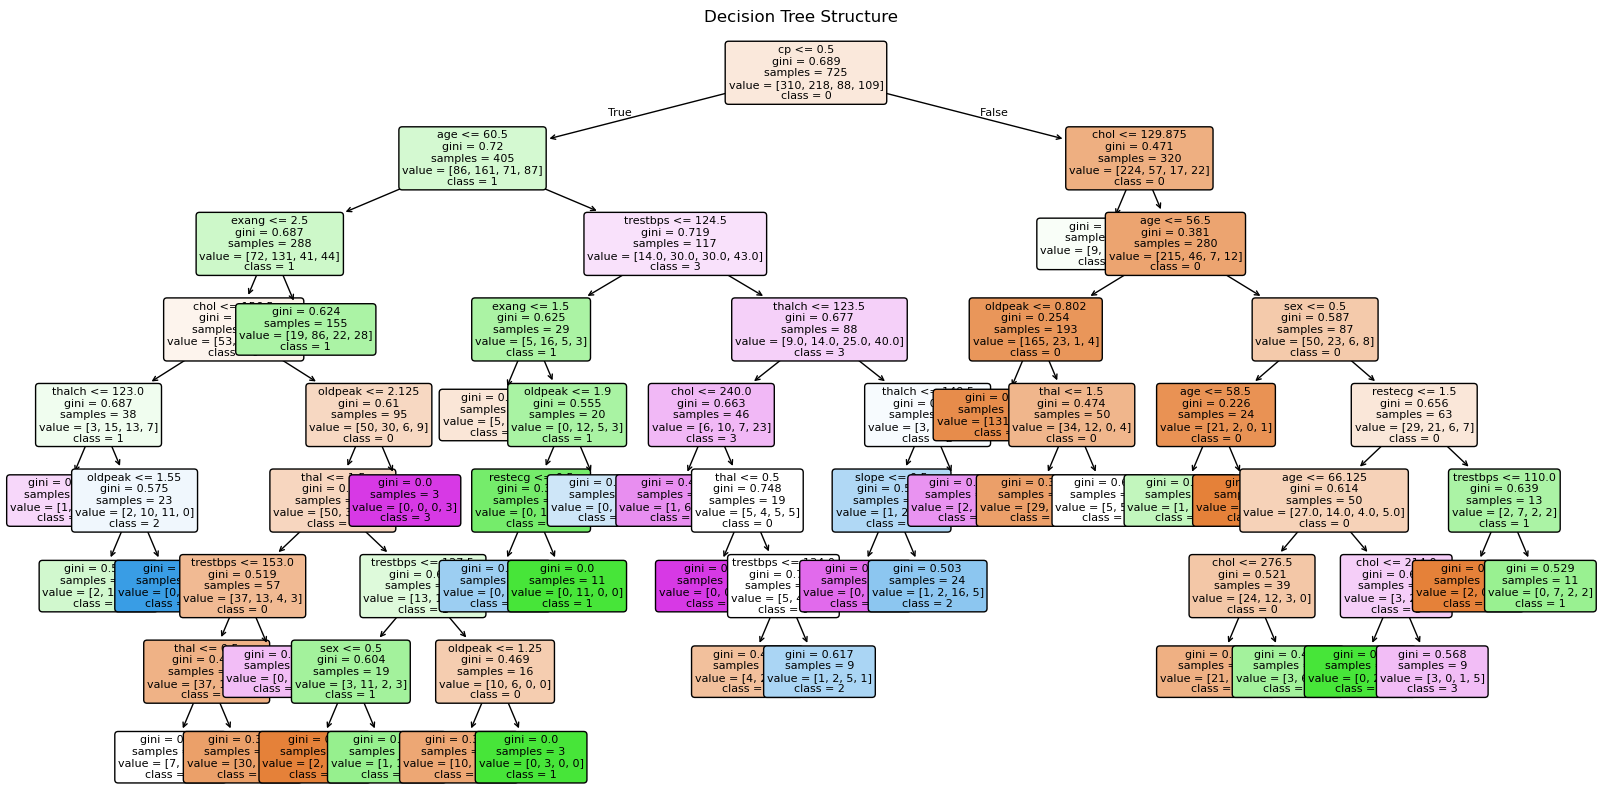

In [47]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=x_train.columns,
    class_names=[str(c) for c in dt.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Structure")
plt.show()


In [48]:
# Importance of Features
importance = dt.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
2         cp    0.306086
4       chol    0.157222
0        age    0.116724
3   trestbps    0.088297
9    oldpeak    0.077561
11      thal    0.065209
8      exang    0.061955
7     thalch    0.046717
1        sex    0.035770
6    restecg    0.031782
10     slope    0.012678
5        fbs    0.000000


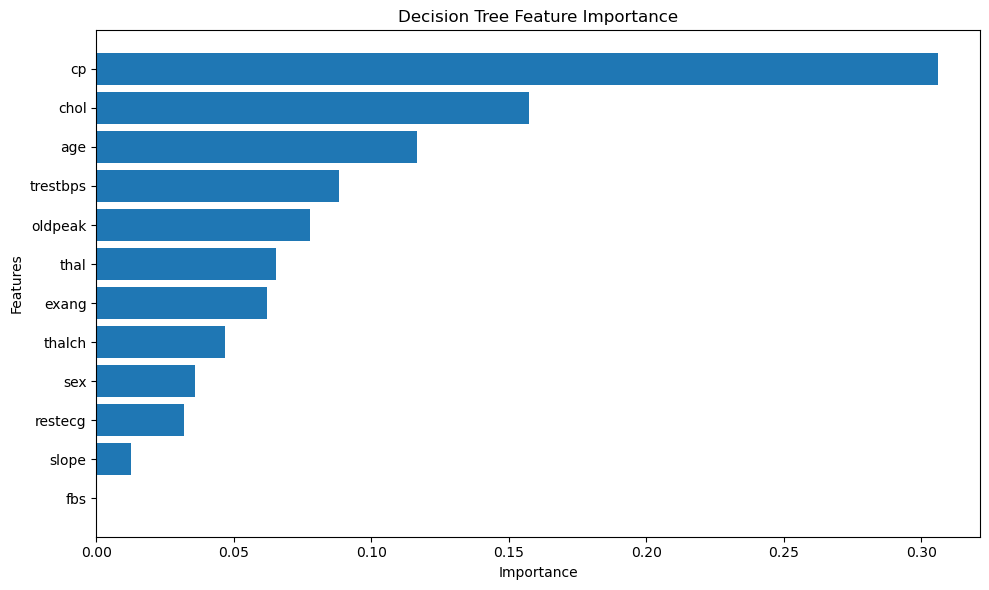

In [49]:
# Visulaize Importance of Features
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [50]:
# Interview Questions:

In [ ]:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

In [ ]:
Hyperparameter	           Purpose	                                    Effect on Model
criterion	          Determines how the best split is selected	      "gini", "entropy", or "log_loss"
max_depth	          Maximum depth of the tree	                      Higher → more complex tree and higher overfitting risk
min_samples_split	  Minimum samples required to split a node	      Higher → simpler tree and less overfitting
min_samples_leaf	  Minimum samples required in a leaf node	      Higher → smoother/simpler tree
max_leaf_nodes	      Maximum number of leaf nodes	                  Higher → more complex tree
max_features	      Number of features considered for each split	  Lower → simpler tree; higher → potentially better fit
class_weight	      Gives different importance to classes	          "balanced" can help with imbalanced data
splitter	          Strategy used to choose the split	              "best" or "random"

In [ ]:
2. What is the difference between the Label encoding and One-hot encoding?

In [ ]:
Feature	                     Label Encoding	                           One-Hot Encoding
Conversion	            Categories → numbers	                    Categories → separate binary columns
Example	                Red → 0, Blue → 1, Green → 2	            Creates Red, Blue, Green columns
Number of columns	    One column	                                Multiple columns
Implies order?	        ⚠️ Can imply an order	                    ❌ No order
Best suited for	        Ordinal categories and tree-based models	Nominal categories
Effect on dimensions	Low	                                        Increases number of features